<a href="https://colab.research.google.com/github/fidanismayilzada23/ML-Projects/blob/main/Boston_House_Prices_Advanced_Regression_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Dataset indirme komutu (Yarışma komutuyla karıştırma, sonunda kullanıcı adı var)
!kaggle datasets download -d fedesoriano/the-boston-houseprice-data

# İnen zip dosyasını klasöre çıkar
!unzip the-boston-houseprice-data.zip

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data
License(s): copyright-authors
100% 12.3k/12.3k [00:00<00:00, 22.3MB/s]

Archive:  the-boston-houseprice-data.zip
  inflating: boston.csv              


In [3]:
df = pd.read_csv('boston.csv')
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


Durum incelemesi

In [5]:
print("Eksik değer sayısı:\n", df.isnull().sum())
print("\n İstatistiksel Özet:")
display(df.describe())

Eksik değer sayısı:
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

 İstatistiksel Özet:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


Görselleştirme


Biz burda fiyat texmini edirik ona göre RM ve LSTAT yaxından baxmalıyıq

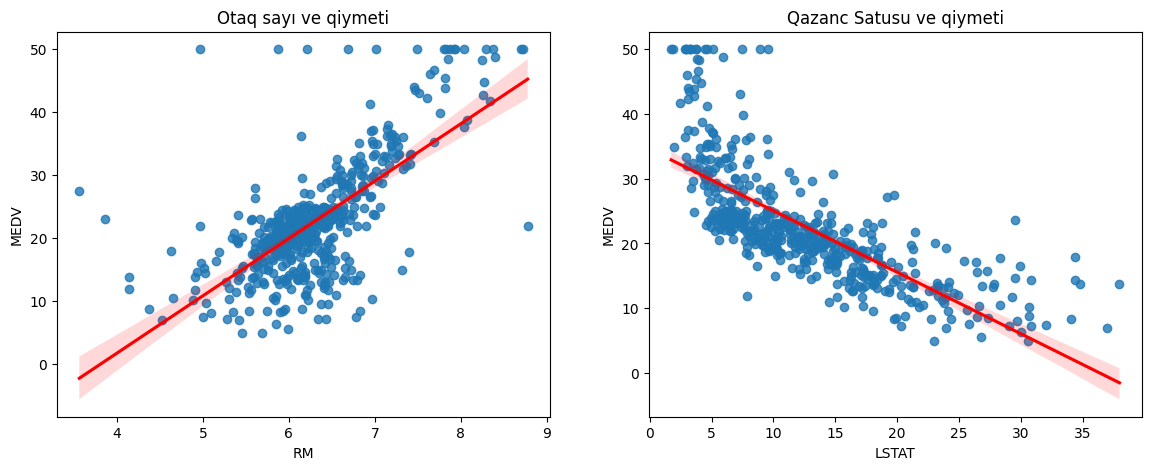

In [6]:
fig, axs= plt.subplots (ncols=2, figsize=(14, 5))


#otaq sayı artdıqca qiymet artırmı?
sns.regplot(x='RM', y='MEDV', data=df, ax=axs[0], line_kws={'color': 'red'})
axs[0].set_title('Otaq sayı ve qiymeti')

#Qazanc düştükce qiymetler artırmı?

sns.regplot(x='LSTAT', y='MEDV', data=df, ax=axs[1], line_kws={'color': 'red'})
axs[1].set_title('Qazanc Satusu ve qiymeti')

plt.show()

Veriyi hazırlayaq (Preprocessing)

Modeli öyretmek üçün
X (Özellikleri) - texmin üçün istifade edeceyimiz verilenler.
Y (Hedef) - Texmin elemek istediyimiz netice (Qiyymet)

Train ve test edeceyik


In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('MEDV', axis=1)
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Öyrenme seti ölçüsü: {X_train.shape}")
print(f"Test seti ölçüsü: {X_test.shape}")

Öyrenme seti ölçüsü: (404, 13)
Test seti ölçüsü: (102, 13)


Model öyretme (Model Training)

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#Model yarat
lr_model = LinearRegression()

#Modeli öyretdiyimiz veri ile öyretsin
lr_model.fit(X_train, y_train)

print("Model uğurlu şekilde öyredildi")

Model uğurlu şekilde öyredildi


Texmin eleme ve Uğuru ölçme

In [11]:
#Test seti üstünde texmin ele
y_pred = lr_model.predict(X_test)

#Uğur metriklerini hesapla
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Xeta payı (RMSE): {rmse:.2f}") #texminlerin ortalama qiymetden ne qeder sapdıqları
print(f"Uğur scoru (R2): {r2:.2f}") #1.00 mükemmel demekdir

Xeta payı (RMSE): 4.93
Uğur scoru (R2): 0.67


Randomforestle eğitme zamanı şimdi

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ilk olaraq modeli tanıdırıq 100 dene ağac qurmasını isteyirik

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

#Modeli öyretdiyimiz veri ile öyretsin
rf_model.fit(X_train, y_train)

#Test verileri üstünde texmin edirik
rf_y_pred =rf_model.predict(X_test)

#Uğuru ölçürük
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_y_pred))
rf_r2 = r2_score(y_test, rf_y_pred)

print(f"Yeni Hata Payı (RMSE): {rf_rmse:.2f}")
print(f"Yeni Başarı Skoru (R2): {rf_r2:.2f}")

Yeni Hata Payı (RMSE): 2.81
Yeni Başarı Skoru (R2): 0.89


Ev qiymetlerini etkileyen en önemli sütunlar

/tmp/ipykernel_9359/813735164.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem', y='Özellik', data=feature_importance_df, palette='viridis')


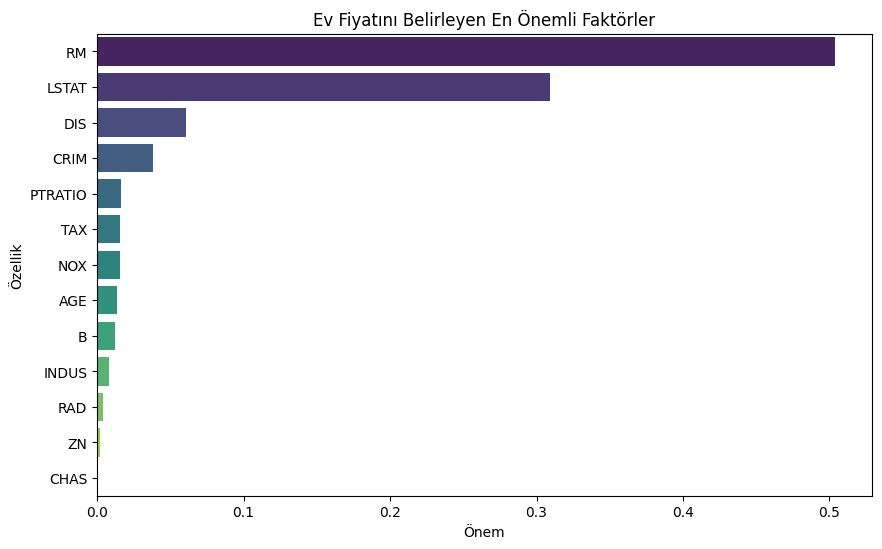

In [13]:
#özelliklerin önem sırası

importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Özellik': feature_names, 'Önem': importances}).sort_values(by='Önem', ascending=False)

# görselleştirme
plt.figure (figsize=(10,6))
sns.barplot(x='Önem', y='Özellik', data=feature_importance_df, palette='viridis')
plt.title('Ev Fiyatını Belirleyen En Önemli Faktörler')
plt.show()